# Save and Load DGGS-Zarr

Save the converted HEALPix data as DGGS-Zarr format following the
[zarr-conventions/dggs](https://github.com/zarr-conventions/dggs) specification,
and verify it can be re-opened with xdggs.

In [1]:
import earthcarekit as eck
import healpix_geo as hpxg
import numpy as np
import xarray as xr
import xdggs
import zarr

from earthcare_dggs.convert import convert_msi_to_healpix
from earthcare_dggs.settings import ELLIPSOID, MSI_DEPTH, MSI_VARIABLES

ORBIT = "06109D"

## Convert MSI data

In [2]:
products = {}
for file_type in ["MSI_CM__2A", "MSI_COP_2A", "MSI_AOT_2A"]:
    try:
        result = eck.search_product(file_type=file_type, orbit_and_frame=ORBIT)
        with eck.read_product(result.filepath[0]) as ds:
            products[file_type] = ds.load()
    except Exception:
        pass

msi_healpix = convert_msi_to_healpix(
    datasets=products, variables=MSI_VARIABLES,
    depth=MSI_DEPTH, ellipsoid=ELLIPSOID,
)

msi_healpix.attrs.update({
    "source": "EarthCARE MSI L2A",
    "orbit_and_frame": ORBIT,
})

msi_healpix = xdggs.decode(
    msi_healpix,
    grid_info=xdggs.HealpixInfo(level=MSI_DEPTH, indexing_scheme="nested"),
)

print(msi_healpix)

<xarray.Dataset> Size: 320MB
Dimensions:                                (cell_ids: 4004112)
Coordinates:
  * cell_ids                               (cell_ids) uint64 32MB 11285471774...
Data variables: (12/18)
    cloud_mask                             (cell_ids) float32 16MB 3.0 ... 3.0
    cloud_type                             (cell_ids) float32 16MB 0.0 ... nan
    cloud_phase                            (cell_ids) float32 16MB 1.0 ... 1.0
    surface_classification                 (cell_ids) float32 16MB -3.276e+04...
    quality_status                         (cell_ids) float32 16MB 0.0 ... 1.0
    cloud_top_height                       (cell_ids) float32 16MB nan ... nan
    ...                                     ...
    isccp_cloud_type                       (cell_ids) float32 16MB -127.0 ......
    aerosol_optical_thickness_670nm        (cell_ids) float32 16MB nan ... nan
    aerosol_optical_thickness_865nm        (cell_ids) float32 16MB nan ... nan
    angstrom_parameter_670n

## Save to DGGS-Zarr

We encode with xdggs convention and add DGGS Zarr convention metadata
including WGS84 ellipsoid information.

In [3]:
# Encode with xdggs convention
msi_encoded = xdggs.encode(msi_healpix, "xdggs")

# Write to Zarr
output_path = f"earthcare_msi_{ORBIT}.zarr"
msi_encoded.to_zarr(output_path, mode="w")

# Add DGGS Zarr convention metadata (compatible with legacy-converters format)
dggs_convention = {
    "uuid": "7b255807-140c-42ca-97f6-7a1cfecdbc38",
    "name": "dggs",
    "schema_url": "https://raw.githubusercontent.com/zarr-conventions/dggs/refs/tags/v1/schema.json",
    "spec_url": "https://github.com/zarr-conventions/dggs/blob/v1/README.md",
    "description": "Discrete Global Grid Systems convention for zarr",
}

dggs_meta = {
    "name": "healpix",
    "refinement_level": MSI_DEPTH,
    "indexing_scheme": "nested",
    "ellipsoid": {
        "name": "wgs84",
        "semimajor_axis": 6378137.0,
        "inverse_flattening": 298.257223563,
    },
    "spatial_dimension": "cell_ids",
    "coordinate": "cell_ids",
    "compression": "none",
}

root = zarr.open_group(output_path, mode="r+")
root.attrs["zarr_conventions"] = [dggs_convention]
root.attrs["dggs"] = dggs_meta

print(f"Saved to {output_path}")
print(f"\nDGGS metadata: {dggs_meta}")

Saved to earthcare_msi_06109D.zarr

DGGS metadata: {'name': 'healpix', 'refinement_level': 17, 'indexing_scheme': 'nested', 'ellipsoid': {'name': 'wgs84', 'semimajor_axis': 6378137.0, 'inverse_flattening': 298.257223563}, 'spatial_dimension': 'cell_ids', 'coordinate': 'cell_ids', 'compression': 'none'}


/Users/annef/Documents/FAIR2Adapt/DGGS/earthcare-dggs/.pixi/envs/dev/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Verify: re-open and decode

In [4]:
ds_check = xr.open_zarr(output_path)
ds_check = xdggs.decode(ds_check)

print(ds_check)
print(f"\nIndex type: {type(ds_check.xindexes['cell_ids'])}")
print(f"Variables: {list(ds_check.data_vars)}")

<xarray.Dataset> Size: 320MB
Dimensions:                                (cell_ids: 4004112)
Coordinates:
  * cell_ids                               (cell_ids) uint64 32MB 11285471774...
Data variables: (12/18)
    aerosol_optical_thickness_670nm        (cell_ids) float32 16MB ...
    aerosol_optical_thickness_670nm_error  (cell_ids) float32 16MB ...
    aerosol_optical_thickness_865nm        (cell_ids) float32 16MB ...
    aerosol_optical_thickness_865nm_error  (cell_ids) float32 16MB ...
    angstrom_parameter_670nm_865nm         (cell_ids) float32 16MB ...
    cloud_effective_radius                 (cell_ids) float32 16MB ...
    ...                                     ...
    cloud_top_temperature_error            (cell_ids) float32 16MB ...
    cloud_type                             (cell_ids) float32 16MB ...
    cloud_water_path                       (cell_ids) float32 16MB ...
    isccp_cloud_type                       (cell_ids) float32 16MB ...
    quality_status              

## Full-resolution zoomed view

Zoom into a 2°×2° region to see the actual cell distribution at the native depth 17 resolution.

Zoomed: 44.0-46.0N, 5.0-7.0E, 134,641 cells


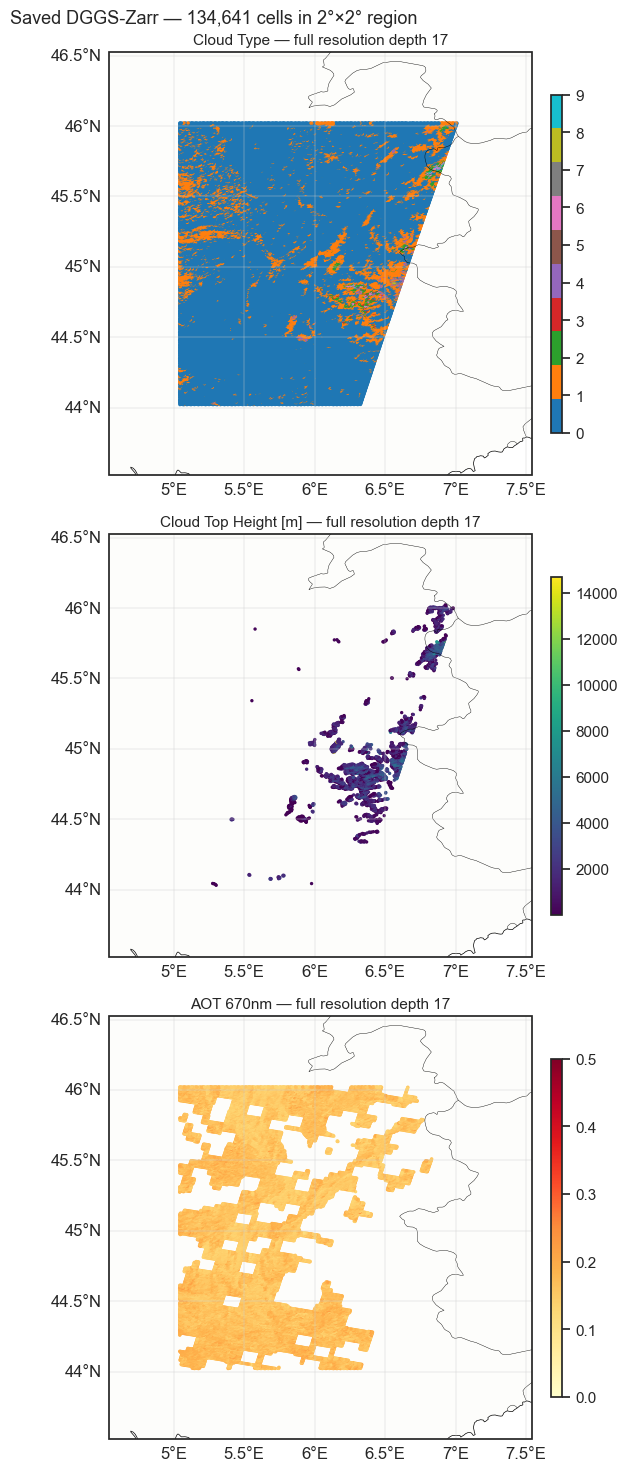

In [5]:
# Full-resolution zoomed view of saved data
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

centers = ds_check.dggs.cell_centers()
cell_lon = centers.longitude.values
cell_lat = centers.latitude.values

# Zoom into a 2x2 degree region
valid = np.isfinite(ds_check["cloud_type"].values) if "cloud_type" in ds_check else np.isfinite(ds_check["cloud_mask"].values)
c_lat, c_lon = np.median(cell_lat[valid]), np.median(cell_lon[valid])
box = 1.0
box_mask = (
    valid &
    (cell_lat > c_lat - box) & (cell_lat < c_lat + box) &
    (cell_lon > c_lon - box) & (cell_lon < c_lon + box)
)
print(f"Zoomed: {c_lat-box:.1f}-{c_lat+box:.1f}N, {c_lon-box:.1f}-{c_lon+box:.1f}E, {box_mask.sum():,} cells")

plot_vars = [
    ("cloud_type", "Cloud Type", "tab10", 0, 9),
    ("cloud_top_height", "Cloud Top Height [m]", "viridis", None, None),
    ("aerosol_optical_thickness_670nm", "AOT 670nm", "YlOrRd", 0, 0.5),
]
plot_vars = [(v, t, c, vn, vx) for v, t, c, vn, vx in plot_vars if v in ds_check]

fig = plt.figure(figsize=(10, 5 * len(plot_vars)))
for j, (var_name, title, cmap, vmin, vmax) in enumerate(plot_vars):
    ax = fig.add_subplot(len(plot_vars), 1, j + 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.1)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.top_labels = False
    gl.right_labels = False

    data = ds_check[var_name].values[box_mask]
    d_mask = np.isfinite(data)
    if d_mask.sum() > 0:
        sc = ax.scatter(
            cell_lon[box_mask][d_mask], cell_lat[box_mask][d_mask],
            c=data[d_mask], s=2, cmap=cmap, vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(),
        )
        plt.colorbar(sc, ax=ax, shrink=0.8, aspect=30, pad=0.02)
    ax.set_extent([c_lon - box - 0.5, c_lon + box + 0.5, c_lat - box - 0.5, c_lat + box + 0.5], crs=ccrs.PlateCarree())
    ax.set_title(f"{title} — full resolution depth {MSI_DEPTH}", fontsize=11)

plt.suptitle(f"Saved DGGS-Zarr — {box_mask.sum():,} cells in 2°×2° region", fontsize=13)
plt.tight_layout()
plt.show()